<a href="https://colab.research.google.com/github/MukeshMoharana/agentcamp-workshop-langchain/blob/main/MIRS_Net_Stage1_Pipeline_Verified.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

IMAGE_DIR = "/content/drive/MyDrive/Datasets/medical datasets/Full_Dataset_Cropped/home/256_cropped/imagesTr"
LABEL_DIR = "/content/drive/MyDrive/Datasets/medical datasets/Full_Dataset_Cropped/home/256_cropped/labelsTr"

images = sorted(os.listdir(IMAGE_DIR))
labels = set(os.listdir(LABEL_DIR))

matched = 0
missing = []

for img in images:

    if not img.endswith(".nii.gz"):
        continue

    case_id = img.replace("_0000.nii.gz", "")

    label1 = case_id + ".nii"
    label2 = case_id + ".nii.gz"

    if label1 in labels or label2 in labels:
        matched += 1
    else:
        missing.append(img)

print(f"Matched: {matched}")
print(f"Missing: {len(missing)}")

if missing:
    print("\nMissing cases:")
    for m in missing:
        print(m)

Matched: 213
Missing: 0


In [ ]:
import os
import nibabel as nib
import numpy as np

IMAGE_DIR = "/content/drive/MyDrive/Datasets/medical datasets/Full_Dataset_Cropped/home/256_cropped/imagesTr"
LABEL_DIR = "/content/drive/MyDrive/Datasets/medical datasets/Full_Dataset_Cropped/home/256_cropped/labelsTr"

# First image
sample = sorted(os.listdir(IMAGE_DIR))[0]

# Build corresponding mask path
case_id = sample.replace("_0000.nii.gz", "")

mask_path = None

if os.path.exists(os.path.join(LABEL_DIR, case_id + ".nii")):
    mask_path = os.path.join(LABEL_DIR, case_id + ".nii")

elif os.path.exists(os.path.join(LABEL_DIR, case_id + ".nii.gz")):
    mask_path = os.path.join(LABEL_DIR, case_id + ".nii.gz")

# Load image
img_path = os.path.join(IMAGE_DIR, sample)

img = nib.load(img_path)

print("IMAGE FILE:", sample)
print("Shape:", img.shape)
print("Spacing:", img.header.get_zooms())

# Load mask
mask = nib.load(mask_path)

print("\nMASK FILE:", os.path.basename(mask_path))
print("Mask Shape:", mask.shape)

print("Unique Labels:")
print(np.unique(mask.get_fdata()))

IMAGE FILE: HN-CMC-30-HypopharynxOropharynxClean_HN00020_20240712_Prospective_0000.nii.gz
Shape: (256, 256, 117)
Spacing: (np.float32(0.9765625), np.float32(0.9765625), np.float32(3.0))

MASK FILE: HN-CMC-30-HypopharynxOropharynxClean_HN00020_20240712_Prospective.nii.gz
Mask Shape: (256, 256, 117)
Unique Labels:
[0. 1.]


In [ ]:
import os
import nibabel as nib
import numpy as np
import pandas as pd

# IMAGE_DIR = "/content/images"

shapes = []
spacings = []

for file in sorted(os.listdir(IMAGE_DIR)):

    if not file.endswith(".nii.gz"):
        continue

    img = nib.load(os.path.join(IMAGE_DIR, file))

    shapes.append(img.shape)

    spacings.append(img.header.get_zooms())

df = pd.DataFrame({
    "shape_x": [s[0] for s in shapes],
    "shape_y": [s[1] for s in shapes],
    "shape_z": [s[2] for s in shapes],
    "spacing_x": [s[0] for s in spacings],
    "spacing_y": [s[1] for s in spacings],
    "spacing_z": [s[2] for s in spacings]
})

print(df.describe())

       shape_x  shape_y     shape_z   spacing_x   spacing_y   spacing_z
count    213.0    213.0  213.000000  213.000000  213.000000  213.000000
mean     256.0    256.0  140.807512    0.976657    0.976657    3.001517
std        0.0      0.0   19.380878    0.000180    0.000180    0.017081
min      256.0    256.0  103.000000    0.976562    0.976562    3.000000
25%      256.0    256.0  134.000000    0.976562    0.976562    3.000000
50%      256.0    256.0  134.000000    0.976562    0.976562    3.000000
75%      256.0    256.0  145.000000    0.976562    0.976562    3.000000
max      256.0    256.0  233.000000    0.977000    0.977000    3.232759


In [ ]:
import os
import nibabel as nib
import numpy as np

# LABEL_DIR = "/content/labels"

sizes = []

for file in sorted(os.listdir(LABEL_DIR)):

    if not (file.endswith(".nii") or file.endswith(".nii.gz")):
        continue

    mask = nib.load(os.path.join(LABEL_DIR, file)).get_fdata()

    sizes.append(np.sum(mask > 0))

print("Min Tumor Voxels :", min(sizes))
print("Max Tumor Voxels :", max(sizes))
print("Mean Tumor Voxels:", np.mean(sizes))

Min Tumor Voxels : 71
Max Tumor Voxels : 112919
Mean Tumor Voxels: 8212.328638497653


In [ ]:

num_cases = 0

for file in sorted(os.listdir(LABEL_DIR)):

    if not file.endswith((".nii", ".nii.gz")):
        continue

    mask = nib.load(os.path.join(LABEL_DIR, file)).get_fdata()

    if np.sum(mask > 0) == 0:
        print("EMPTY MASK:", file)

    num_cases += 1

print("Cases checked:", num_cases)

Cases checked: 213


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
SEED = 42

images = sorted([
    f for f in os.listdir(IMAGE_DIR)
    if f.endswith(".nii.gz")
])

case_ids = [
    img.replace("_0000.nii.gz", "")
    for img in images
]

train_cases, temp_cases = train_test_split(
    case_ids,
    test_size=64,
    random_state=SEED
)

val_cases, test_cases = train_test_split(
    temp_cases,
    test_size=32,
    random_state=SEED
)

print("Train:", len(train_cases))
print("Val:", len(val_cases))
print("Test:", len(test_cases))

Train: 149
Val: 32
Test: 32


In [ ]:
SPLIT_DIR = "/content/drive/MyDrive/MIRS-Net/splits"

os.makedirs(SPLIT_DIR, exist_ok=True)

with open(os.path.join(SPLIT_DIR, "train.txt"), "w") as f:
    f.write("\n".join(train_cases))

with open(os.path.join(SPLIT_DIR, "val.txt"), "w") as f:
    f.write("\n".join(val_cases))

with open(os.path.join(SPLIT_DIR, "test.txt"), "w") as f:
    f.write("\n".join(test_cases))

print("Splits saved.")

Splits saved.


In [ ]:
rows = []

for case_id in case_ids:

    image_path = os.path.join(
        IMAGE_DIR,
        case_id + "_0000.nii.gz"
    )

    mask_path = os.path.join(
        LABEL_DIR,
        case_id + ".nii.gz"
    )

    if case_id in train_cases:
        split = "train"

    elif case_id in val_cases:
        split = "val"

    else:
        split = "test"

    rows.append({
        "case_id": case_id,
        "image_path": image_path,
        "mask_path": mask_path,
        "split": split
    })

metadata = pd.DataFrame(rows)

metadata_path = "/content/drive/MyDrive/MIRS-Net/metadata.csv"

metadata.to_csv(
    metadata_path,
    index=False
)

print(metadata.head())
print()
print("Total Cases:", len(metadata))

                                             case_id  \
0  HN-CMC-30-HypopharynxOropharynxClean_HN00020_2...   
1  HN-CMC-30-HypopharynxOropharynxClean_HN00021_2...   
2  HN-CMC-30-HypopharynxOropharynxClean_HN00024_2...   
3  HN-CMC-30-HypopharynxOropharynxClean_HN00028_2...   
4  HN-CMC-30-HypopharynxOropharynxClean_HN00035_2...   

                                          image_path  \
0  /content/drive/MyDrive/Datasets/medical datase...   
1  /content/drive/MyDrive/Datasets/medical datase...   
2  /content/drive/MyDrive/Datasets/medical datase...   
3  /content/drive/MyDrive/Datasets/medical datase...   
4  /content/drive/MyDrive/Datasets/medical datase...   

                                           mask_path  split  
0  /content/drive/MyDrive/Datasets/medical datase...  train  
1  /content/drive/MyDrive/Datasets/medical datase...  train  
2  /content/drive/MyDrive/Datasets/medical datase...  train  
3  /content/drive/MyDrive/Datasets/medical datase...  train  
4  /content/driv

In [ ]:
df = pd.read_csv(metadata_path)

print(df["split"].value_counts())

split
train    149
test      32
val       32
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
def generate_2d_bbox(
        mask,
        min_margin=5,
        max_margin=20):

    # Find slices containing tumor
    tumor_slices = np.where(
        np.sum(mask > 0, axis=(0,1)) > 0
    )[0]

    # Random tumor slice
    selected_slice = np.random.choice(
        tumor_slices
    )

    mask_slice = mask[:,:,selected_slice]

    coords = np.argwhere(
        mask_slice > 0
    )

    ymin, xmin = coords.min(axis=0)
    ymax, xmax = coords.max(axis=0)

    margin = np.random.randint(
        min_margin,
        max_margin + 1
    )

    xmin = max(0, xmin - margin)
    ymin = max(0, ymin - margin)

    xmax = min(
        mask.shape[0]-1,
        xmax + margin
    )

    ymax = min(
        mask.shape[1]-1,
        ymax + margin
    )

    return {
        "slice_idx": selected_slice,
        "bbox": [
            xmin,
            ymin,
            xmax,
            ymax
        ]
    }

In [ ]:
def create_prompt_volume(
        shape,
        slice_idx,
        bbox,
        radius=3):

    prompt = np.zeros(
        shape,
        dtype=np.float32
    )

    xmin,ymin,xmax,ymax = bbox

    start_slice = max(
        0,
        slice_idx - radius
    )

    end_slice = min(
        shape[2]-1,
        slice_idx + radius
    )

    for z in range(
        start_slice,
        end_slice + 1
    ):

        prompt[
            xmin:xmax,
            ymin:ymax,
            z
        ] = 1.0

    return prompt

In [ ]:
sample_mask = nib.load(
    mask_path
).get_fdata()

bbox_info = generate_2d_bbox(
    sample_mask
)

print(
    "Selected Slice:",
    bbox_info["slice_idx"]
)

print(
    "BBox:",
    bbox_info["bbox"]
)

prompt = create_prompt_volume(
    sample_mask.shape,
    bbox_info["slice_idx"],
    bbox_info["bbox"]
)

print(
    "Prompt Shape:",
    prompt.shape
)

Selected Slice: 74
BBox: [np.int64(73), np.int64(85), np.int64(141), np.int64(181)]
Prompt Shape: (256, 256, 134)


In [ ]:
def visualize_prompt(case_row):

    image = nib.load(
        case_row["image_path"]
    ).get_fdata()

    mask = nib.load(
        case_row["mask_path"]
    ).get_fdata()

    bbox_info = generate_2d_bbox(
        mask
    )

    slice_idx = bbox_info[
        "slice_idx"
    ]

    xmin,ymin,xmax,ymax = bbox_info[
        "bbox"
    ]

    img_slice = image[
        :,
        :,
        slice_idx
    ]

    mask_slice = mask[
        :,
        :,
        slice_idx
    ]

    plt.figure(
        figsize=(8,8)
    )

    plt.imshow(
        img_slice,
        cmap="gray"
    )

    plt.imshow(
        np.ma.masked_where(
            mask_slice == 0,
            mask_slice
        ),
        alpha=0.5
    )

    plt.plot(
        [xmin,xmax,xmax,xmin,xmin],
        [ymin,ymin,ymax,ymax,ymin],
        linewidth=2
    )

    plt.title(
        f"{case_row['case_id']} | Slice {slice_idx}"
    )

    plt.axis("off")

    plt.show()

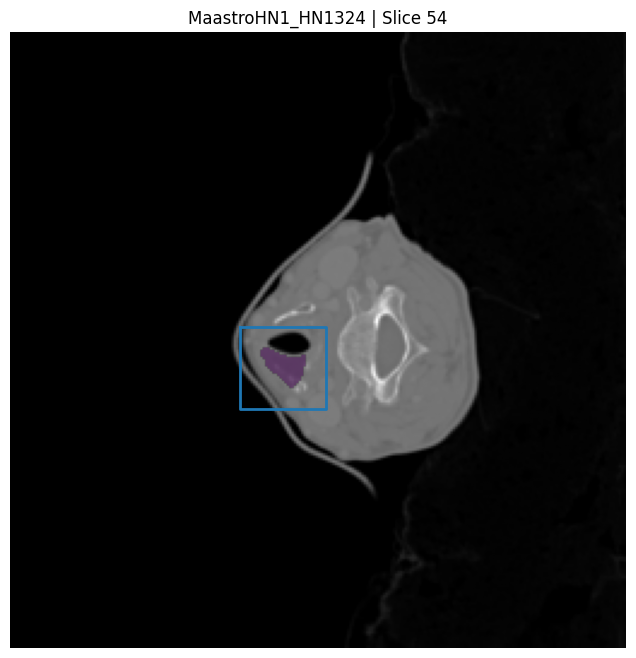

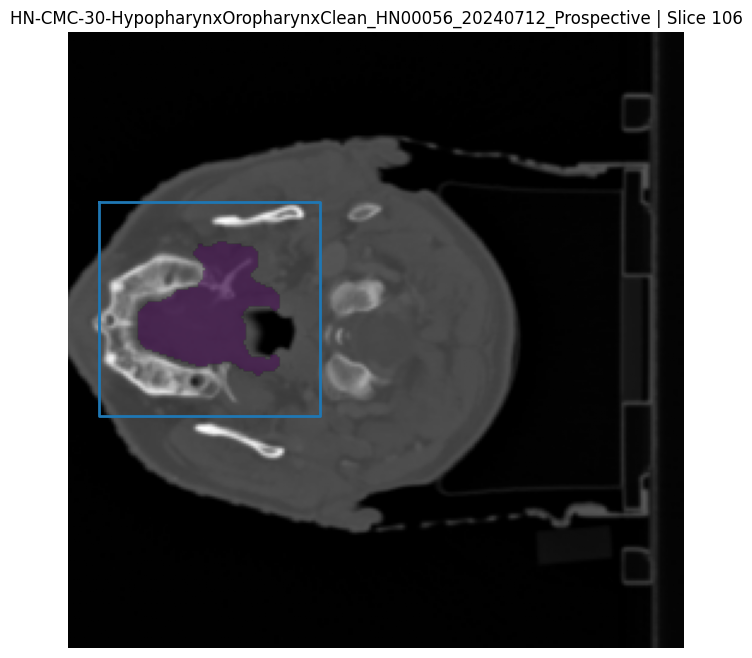

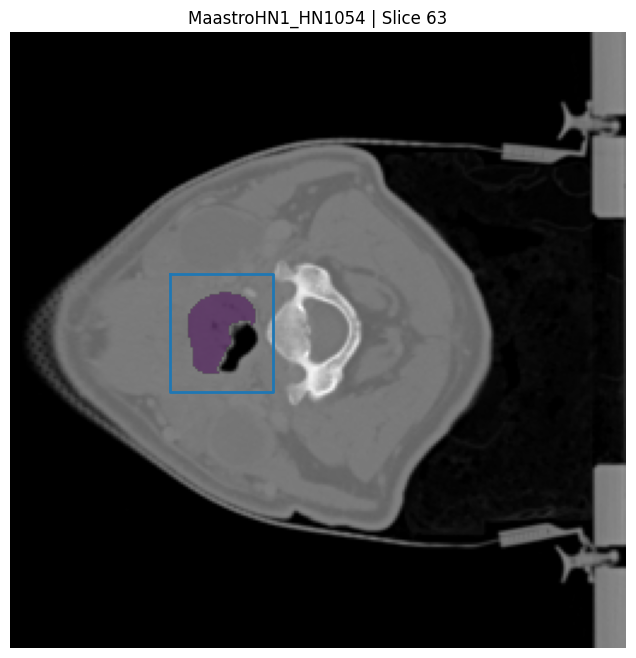

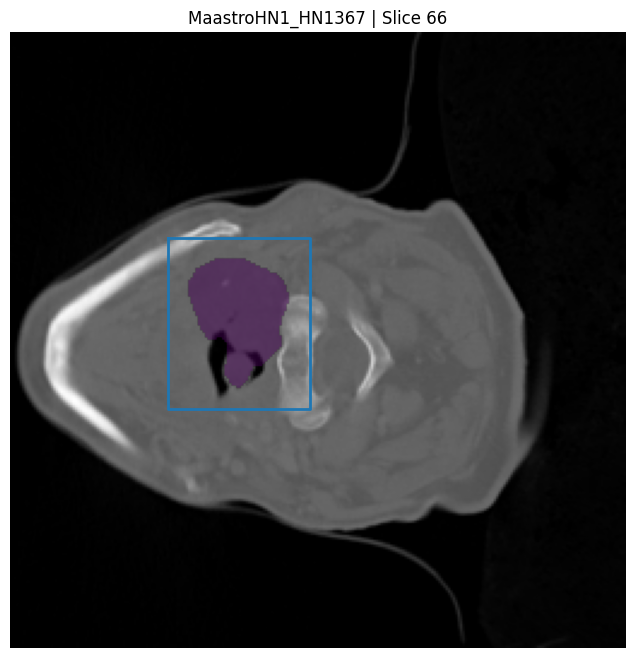

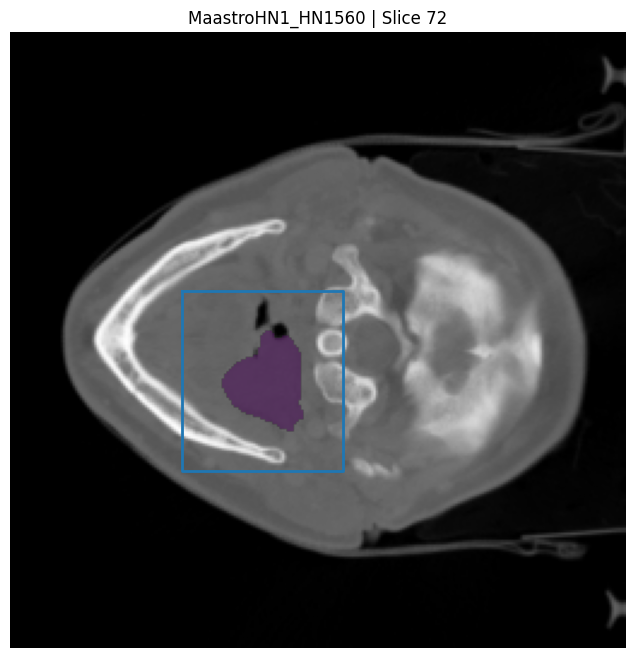

In [ ]:
import random

df = pd.read_csv(
    metadata_path
)

for _ in range(5):

    idx = random.randint(
        0,
        len(df)-1
    )

    visualize_prompt(
        df.iloc[idx]
    )

In [ ]:
import torch
from torch.utils.data import Dataset
class HNCDataset(Dataset):

    def __init__(self,
                 metadata_csv,
                 split):

        self.df = pd.read_csv(metadata_csv)

        self.df = self.df[
            self.df["split"] == split
        ].reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = nib.load(
            row["image_path"]
        ).get_fdata()

        mask = nib.load(
            row["mask_path"]
        ).get_fdata()

        # -------------------------
        # intensity normalization
        # -------------------------

        image = image.astype(np.float32)

        image = (
            image - image.mean()
        ) / (
            image.std() + 1e-8
        )

        # -------------------------
        # prompt generation
        # -------------------------

        bbox_info = generate_2d_bbox(mask)

        prompt = create_prompt_volume(
            image.shape,
            bbox_info["slice_idx"],
            bbox_info["bbox"],
            radius=3
        )

        # -------------------------
        # convert to channels-first
        # -------------------------

        image = np.transpose(
            image,
            (2, 0, 1)
        )

        prompt = np.transpose(
            prompt,
            (2, 0, 1)
        )

        mask = np.transpose(
            mask,
            (2, 0, 1)
        )
        image, mask, prompt = extract_foreground_patch(
            image,
            mask,
            prompt,
            patch_size=(96,96,96)
        )

        input_tensor = np.stack(
            [image, prompt],
            axis=0
        )


        return {
            "image": torch.tensor(
                input_tensor,
                dtype=torch.float32
            ),

            "mask": torch.tensor(
                mask,
                dtype=torch.float32
            )
        }


In [ ]:
train_dataset = HNCDataset(
    metadata_csv=metadata_path,
    split="train"
)

sample = train_dataset[0]

print(
    "Input:",
    sample["image"].shape
)

print(
    "Mask:",
    sample["mask"].shape
)

Input: torch.Size([2, 96, 96, 96])
Mask: torch.Size([96, 96, 96])


In [ ]:
sample = train_dataset[0]

print(sample["image"].shape)
print(sample["mask"].shape)

torch.Size([2, 96, 96, 96])
torch.Size([96, 96, 96])


In [ ]:
sample = train_dataset[0]

print("Image dtype:", sample["image"].dtype)
print("Mask dtype:", sample["mask"].dtype)

print("Image min:", sample["image"][0].min())
print("Image max:", sample["image"][0].max())

print("Prompt unique:",
      torch.unique(sample["image"][1]))

print("Mask unique:",
      torch.unique(sample["mask"]))

Image dtype: torch.float32
Mask dtype: torch.float32
Image min: tensor(-0.7875)
Image max: tensor(6.4164)
Prompt unique: tensor([0., 1.])
Mask unique: tensor([0., 1.])


In [ ]:
def extract_foreground_patch(
    image,
    mask,
    prompt,
    patch_size=(96,96,96)
):
    tumor_voxels = np.argwhere(mask > 0)

    if len(tumor_voxels) == 0:
        raise ValueError("Empty mask found")

    center_idx = np.random.randint(len(tumor_voxels))
    cz, cy, cx = tumor_voxels[center_idx]

    hz, hy, hx = [p // 2 for p in patch_size]

    image = np.pad(
        image,
        ((hz,hz),(hy,hy),(hx,hx)),
        mode="constant"
    )

    mask = np.pad(
        mask,
        ((hz,hz),(hy,hy),(hx,hx)),
        mode="constant"
    )

    prompt = np.pad(
        prompt,
        ((hz,hz),(hy,hy),(hx,hx)),
        mode="constant"
    )

    cz += hz
    cy += hy
    cx += hx

    image_patch = image[
        cz-hz:cz+hz,
        cy-hy:cy+hy,
        cx-hx:cx+hx
    ]

    mask_patch = mask[
        cz-hz:cz+hz,
        cy-hy:cy+hy,
        cx-hx:cx+hx
    ]

    prompt_patch = prompt[
        cz-hz:cz+hz,
        cy-hy:cy+hy,
        cx-hx:cx+hx
    ]

    return image_patch, mask_patch, prompt_patch

In [ ]:
sample_dict = train_dataset[0]

sample_input = sample_dict['image']
sample_mask = sample_dict['mask']

print(type(sample_input))
print(type(sample_mask))

print(sample_input.shape)
print(sample_mask.shape)

<class 'torch.Tensor'>
<class 'torch.Tensor'>
torch.Size([2, 96, 96, 96])
torch.Size([96, 96, 96])


In [ ]:
image = sample_input[0].numpy()
prompt = sample_input[1].numpy()

mask = sample_mask.numpy()

print(image.shape)
print(prompt.shape)
print(mask.shape)

(96, 96, 96)
(96, 96, 96)
(96, 96, 96)


In [ ]:
image_patch, mask_patch, prompt_patch = extract_foreground_patch(
    image,
    mask,
    prompt
)

print("Image Patch:", image_patch.shape)
print("Mask Patch :", mask_patch.shape)
print("Prompt Patch:", prompt_patch.shape)

print("Tumor Voxels:", mask_patch.sum())
print("Prompt Voxels:", prompt_patch.sum())

Image Patch: (96, 96, 96)
Mask Patch : (96, 96, 96)
Prompt Patch: (96, 96, 96)
Tumor Voxels: 7572.0
Prompt Voxels: 19635.0


In [ ]:
for i in range(5):

    sample = train_dataset[i]

    print(
        sample["image"].shape,
        sample["mask"].sum().item()
    )

torch.Size([2, 96, 96, 96]) 7572.0
torch.Size([2, 96, 96, 96]) 702.0
torch.Size([2, 96, 96, 96]) 34463.0
torch.Size([2, 96, 96, 96]) 2918.0
torch.Size([2, 96, 96, 96]) 2523.0


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=2
)

In [ ]:
batch = next(iter(train_loader))

print(batch["image"].shape)
print(batch["mask"].shape)

torch.Size([2, 2, 96, 96, 96])
torch.Size([2, 96, 96, 96])


In [ ]:
pip install -q monai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 27.4 MB/s eta 0:00:00


In [ ]:
import monai

print(monai.__version__)

1.5.2


In [ ]:
from monai.networks.nets import SwinUNETR

model = SwinUNETR(
    in_channels=2,
    out_channels=2,
    feature_size=48,
    patch_size=2,
    use_checkpoint=True
)

In [ ]:
import inspect
from monai.networks.nets import SwinUNETR

print(inspect.signature(SwinUNETR))

(in_channels: 'int', out_channels: 'int', patch_size: 'int' = 2, depths: 'Sequence[int]' = (2, 2, 2, 2), num_heads: 'Sequence[int]' = (3, 6, 12, 24), window_size: 'Sequence[int] | int' = 7, qkv_bias: 'bool' = True, mlp_ratio: 'float' = 4.0, feature_size: 'int' = 24, norm_name: 'tuple | str' = 'instance', drop_rate: 'float' = 0.0, attn_drop_rate: 'float' = 0.0, dropout_path_rate: 'float' = 0.0, normalize: 'bool' = True, norm_layer: 'type[LayerNorm]' = <class 'torch.nn.modules.normalization.LayerNorm'>, patch_norm: 'bool' = False, use_checkpoint: 'bool' = False, spatial_dims: 'int' = 3, downsample: 'str | nn.Module' = 'merging', use_v2: 'bool' = False) -> 'None'


In [ ]:
x = torch.randn(1, 2, 96, 96, 96)

y = model(x)

print(y.shape)

torch.Size([1, 2, 96, 96, 96])


In [ ]:
batch = next(iter(train_loader))

print(batch["image"].shape)
print(batch["mask"].shape)

print(batch["mask"].dtype)

print(torch.unique(batch["mask"]))

torch.Size([2, 2, 96, 96, 96])
torch.Size([2, 96, 96, 96])
torch.float32
tensor([0., 1.])


In [ ]:
from monai.losses import DiceCELoss

loss_fn = DiceCELoss(
    to_onehot_y=True,
    softmax=True
)

In [ ]:
device = "cpu"

model = model.to(device)

batch = next(iter(train_loader))

images = batch["image"].to(device)

masks = batch["mask"].long().to(device)

outputs = model(images)

loss = loss_fn(
    outputs,
    masks.unsqueeze(1)
)

print(loss.item())

1.285485029220581
